# Machine learning and Deep Learning titanic

#### Let us test without applying any data balancing techniques, using the following algorithms: Ensemble Voting, Deep Neural Networks, Random Forest, K-Nearest Neighbors (KNN), Logistic Regression, Support Vector Machine (SVM), and XGBoost

In [222]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as srn
import statistics as sts
import tensorflow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.ensemble import RandomForestClassifier
from yellowbrick.classifier import ConfusionMatrix
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier



In [223]:
data_train = pd.read_csv('titanic_tratado.csv')
data_test = pd.read_csv('titanic_tratado_test.csv')

In [224]:
data_train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22,1,0,7,1,0,1
1,1,1,38,1,0,71,0,0,0
2,1,3,26,0,0,7,0,0,1
3,1,1,35,1,0,53,0,0,1
4,0,3,35,0,0,8,1,0,1


In [225]:
data_test.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,34,0,0,7,1,1,0
1,3,47,1,0,7,0,0,1
2,2,62,0,0,9,1,1,0
3,3,27,0,0,8,1,0,1
4,3,22,1,1,12,0,0,1


In [226]:
# Normalize numerical columns
scaler = MinMaxScaler()
data_train[['Age', 'Fare']] = scaler.fit_transform(data_train[['Age', 'Fare']])
data_test[['Age', 'Fare']] = scaler.fit_transform(data_test[['Age', 'Fare']])

In [227]:
data_train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,0.2750,1,0,0.013672,1,0,1
1,1,1,0.4750,1,0,0.138672,0,0,0
2,1,3,0.3250,0,0,0.013672,0,0,1
3,1,1,0.4375,1,0,0.103516,0,0,1
4,0,3,0.4375,0,0,0.015625,1,0,1


In [228]:
data_test.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,0.447368,0,0,0.013672,1,1,0
1,3,0.618421,1,0,0.013672,0,0,1
2,2,0.815789,0,0,0.017578,1,1,0
3,3,0.355263,0,0,0.015625,1,0,1
4,3,0.289474,1,1,0.023438,0,0,1


In [229]:
# Split between train and test
X = data_train.drop(columns=['Survived'])
y = data_train['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [230]:
X_train.shape,y_train.shape,

((712, 8), (712,))

In [231]:
 X_test.shape,  y_test.shape

((179, 8), (179,))

## Let’s start by training the machine learning algorithms, and then move on to deep neural networks.

#### Random forest

In [232]:
random_model = RandomForestClassifier(n_estimators=40)
random_model

RandomForestClassifier(n_estimators=40)

In [233]:
random_model.fit(X_train,y_train)


RandomForestClassifier(n_estimators=40)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.8100558659217877

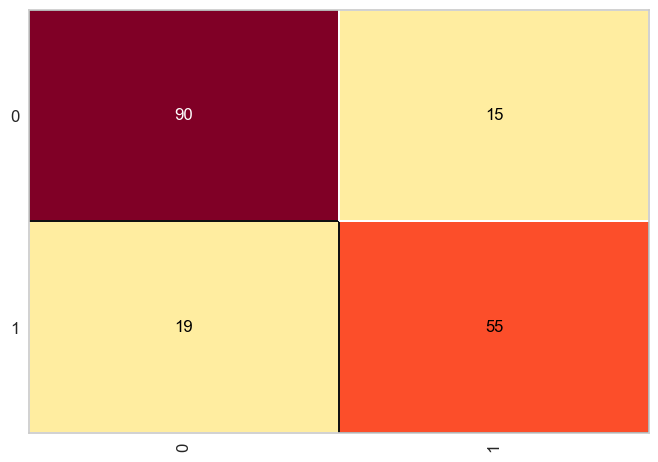

In [234]:
cm = ConfusionMatrix(random_model)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### KNN

In [235]:
knn = KNeighborsClassifier(n_neighbors=5 , metric="minkowski", p = 2) # maneira que o calculo da distancia sera feita no metric
knn.fit(X_train, y_train)

KNeighborsClassifier()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


0.8100558659217877

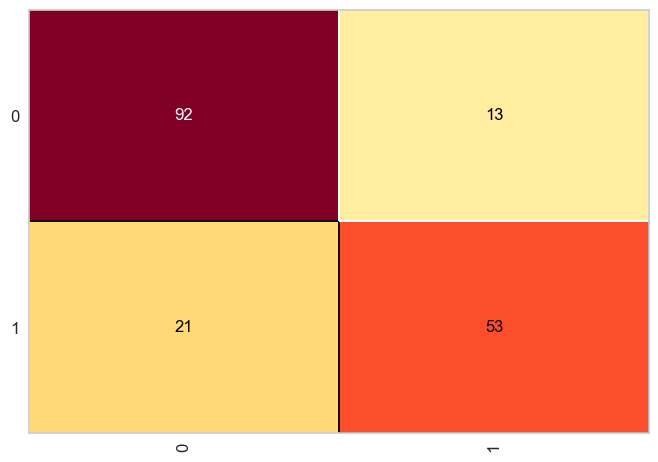

In [236]:
cm = ConfusionMatrix(knn)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### SVM

In [237]:
svm = SVC(kernel='sigmoid')  
svm.fit(X_train, y_train)

SVC(kernel='sigmoid')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


0.6145251396648045

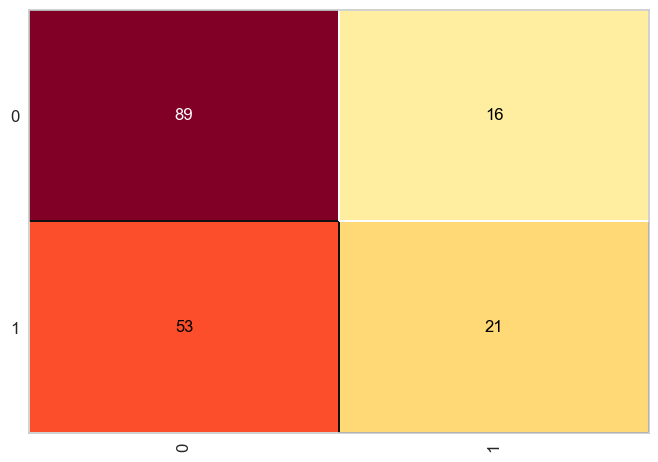

In [238]:
cm = ConfusionMatrix(svm)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### Logistic Regression

In [239]:
from sklearn.linear_model import LogisticRegression


In [240]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)

LogisticRegression()

In [241]:
y_pred = logistic_model.predict(X_test)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


0.7988826815642458

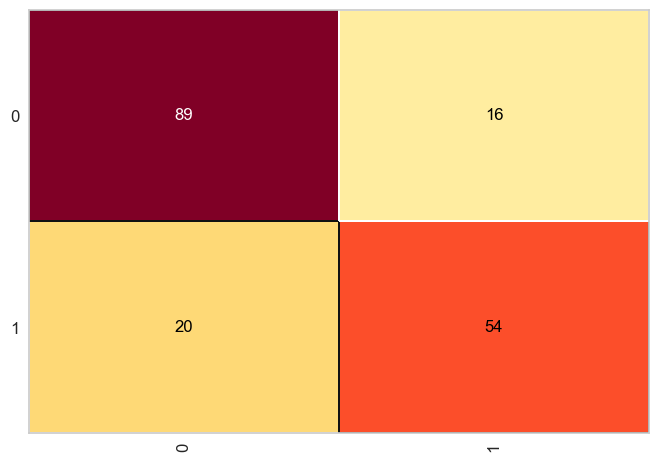

In [242]:
cm = ConfusionMatrix(logistic_model)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### XGBOOST

In [243]:
xgboost = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss')
xgboost.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

0.8268156424581006

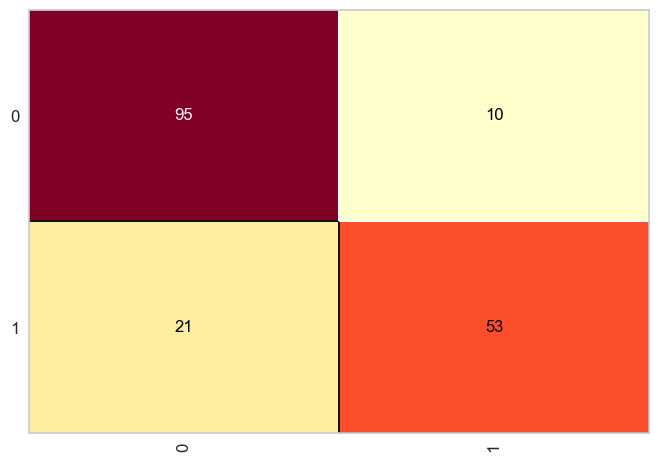

In [244]:
cm = ConfusionMatrix(xgboost)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### ensemble voting

In [246]:

svm = SVC(kernel='sigmoid', probability=True)
knn = KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2)
rf = RandomForestClassifier(n_estimators=40)
logistic_model = LogisticRegression()
xgboost = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss')

# Create ensemble
ensemble = VotingClassifier(
    estimators=[
        ('logistic', logistic_model),
        ('knn', knn),
        ('rf', rf),
        ('xgboost', xgboost)
    ],
    voting='soft', 
    weights=[1, 1, 1, 2]  
)

In [247]:
ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


0.8379888268156425

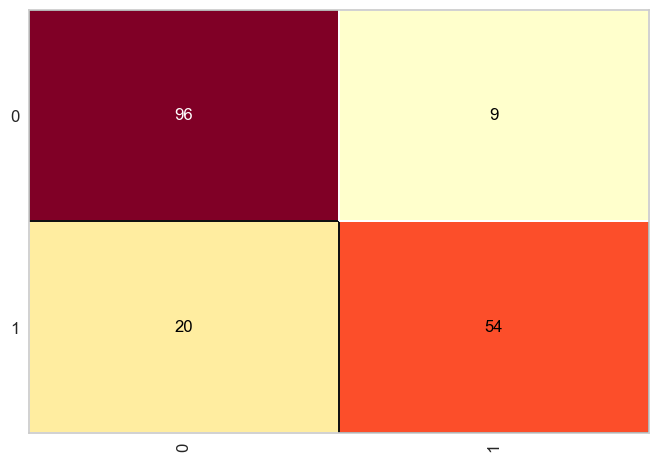

In [248]:
cm = ConfusionMatrix(ensemble)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### Deep learning

##### Because of hardware limitation we will not use gridsearch to find the best model

In [249]:
import tensorflow as tf

deep_learning_model = Sequential([
    tf.keras.layers.InputLayer(shape = (X.shape[1],)),
    tf.keras.layers.Dense(units = 32, activation = 'relu', kernel_initializer='random_uniform'), 
    tf.keras.layers.Dropout(rate = 0.2),
    tf.keras.layers.Dense(units = 16, activation = 'relu', kernel_initializer='random_uniform'), 
    tf.keras.layers.Dropout(rate = 0.2),
    tf.keras.layers.Dense(units = 1, activation = 'sigmoid') 
]) 

In [250]:
deep_learning_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [251]:
optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001, clipvalue = 0.5) # os pesos nao vao passar esse valor o clipValue

In [252]:
deep_learning_model.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['binary_accuracy'])

In [253]:
deep_learning_model.fit(X_train, y_train, epochs=200, batch_size=16, validation_split=0.2)

Epoch 1/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.5609 - loss: 0.6898 - val_binary_accuracy: 0.6503 - val_loss: 0.6664
Epoch 2/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step - binary_accuracy: 0.6097 - loss: 0.6655 - val_binary_accuracy: 0.6503 - val_loss: 0.6174
Epoch 3/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step - binary_accuracy: 0.6267 - loss: 0.6225 - val_binary_accuracy: 0.6503 - val_loss: 0.5852
Epoch 4/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step - binary_accuracy: 0.5806 - loss: 0.6297 - val_binary_accuracy: 0.6783 - val_loss: 0.5584
Epoch 5/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - binary_accuracy: 0.6794 - loss: 0.5862 - val_binary_accuracy: 0.7343 - val_loss: 0.5277
Epoch 6/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - binary_accuracy: 0.7244 - loss: 0.5782 - val_binary_accuracy: 0.7832 - val_loss: 0.5007
Epoch 7/200
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step - binary_accuracy: 0.7489 - loss: 0.5451 - val_binary_accuracy: 0.8182 - val_loss: 0.4830
E

In [254]:
loss, accuracy = deep_learning_model.evaluate(X_test, y_test)
print(f"Accuracy on the test set: {accuracy:.2f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8055 - loss: 0.4174 
Accuracy on the test set: 0.80


#### Let’s test by applying balancing techniques to the same algorithms and see if we achieve better results.

##### Undersampling - Tomek links

In [255]:
from collections import Counter
from imblearn.under_sampling import TomekLinks


In [256]:
print("Before Tomek Links:", Counter(y))

Before Tomek Links: Counter({0: 549, 1: 342})


In [206]:
tl = TomekLinks(sampling_strategy='majority') 
X_res, y_res = tl.fit_resample(X, y)

print("After Tomek Links:", Counter(y_res))

Depois do Tomek Links: Counter({0: 505, 1: 342})


In [207]:
X_res.shape, y_res.shape

((847, 8), (847,))

In [208]:
X_res.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0.4750,1,0,0.138672,0,0,0
1,3,0.3250,0,0,0.013672,0,0,1
2,1,0.4375,1,0,0.103516,0,0,1
3,3,0.4375,0,0,0.015625,1,0,1
4,3,0.3500,0,0,0.015625,1,1,0


In [209]:
y_res.head()

0    1
1    1
2    1
3    0
4    0
Name: Survived, dtype: int64

In [210]:
# Split data from tomek
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)


#### Random forest

In [211]:
random_model.fit(X_train,y_train)


RandomForestClassifier(n_estimators=40)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.8058823529411765

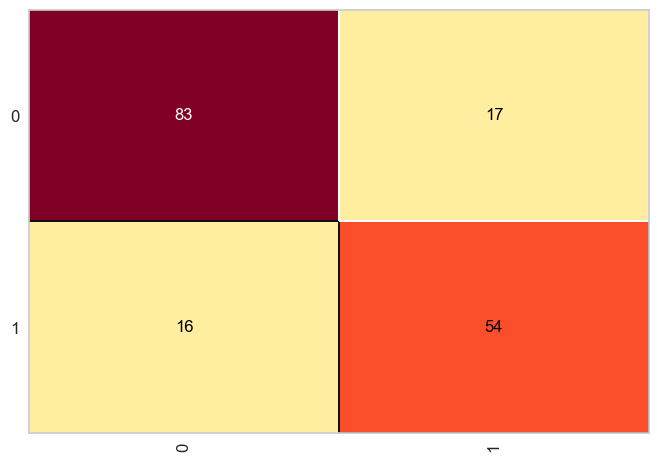

In [212]:
cm = ConfusionMatrix(random_model)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### KNN

In [213]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


0.8

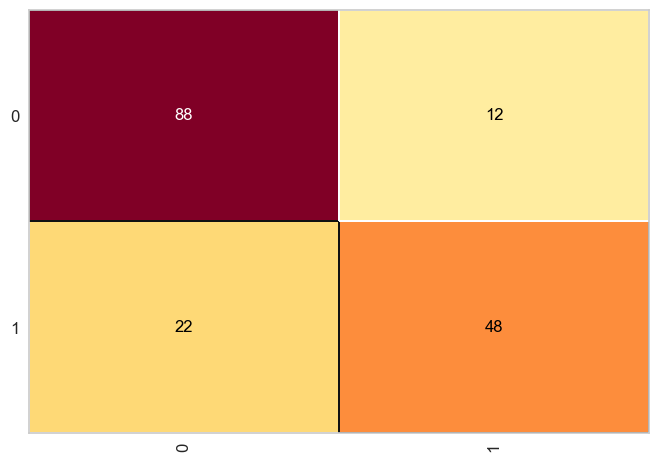

In [214]:
cm = ConfusionMatrix(knn)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### SVM

In [215]:
svm.fit(X_train, y_train)

SVC(kernel='sigmoid')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


0.6352941176470588

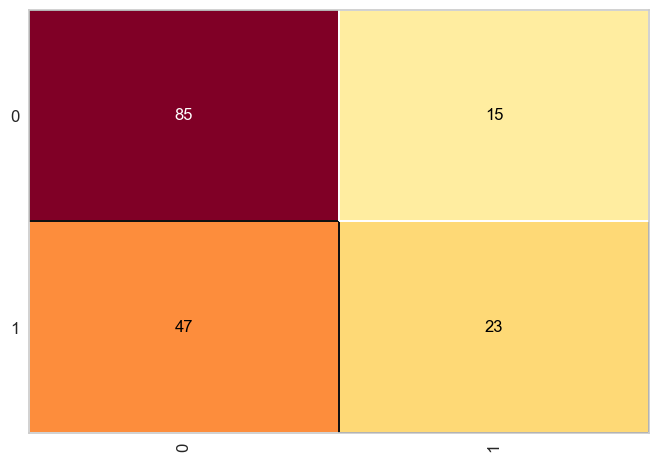

In [216]:
cm = ConfusionMatrix(svm)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

### Logistic Regression

In [217]:
logistic_model.fit(X_train, y_train)

LogisticRegression()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


0.8058823529411765

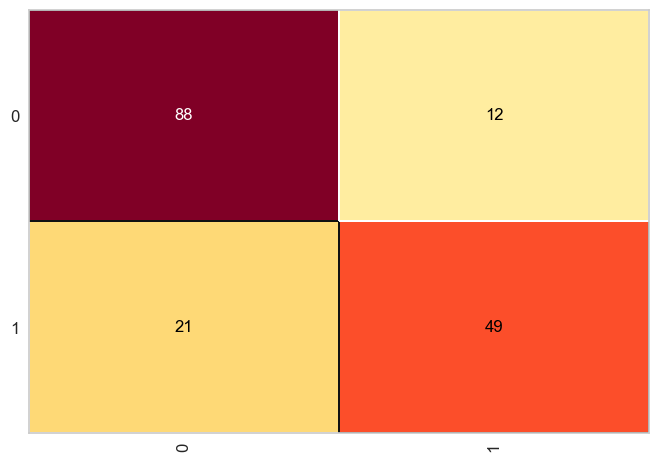

In [218]:
cm = ConfusionMatrix(logistic_model)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### XGBOOST

In [219]:
xgboost = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss')
xgboost.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

0.8470588235294118

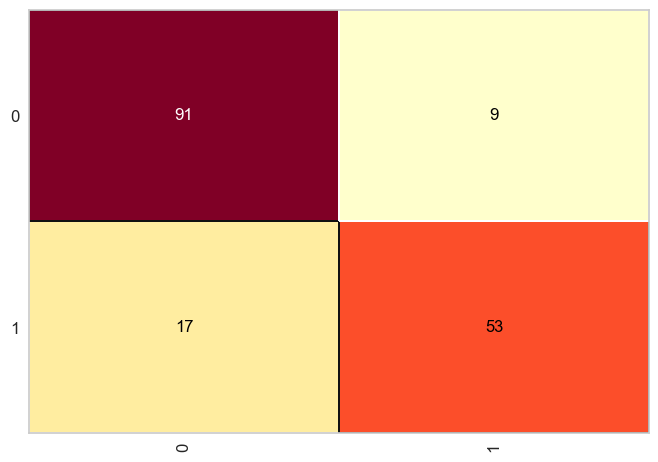

In [220]:
cm = ConfusionMatrix(xgboost)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### Ensemble

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


0.8470588235294118

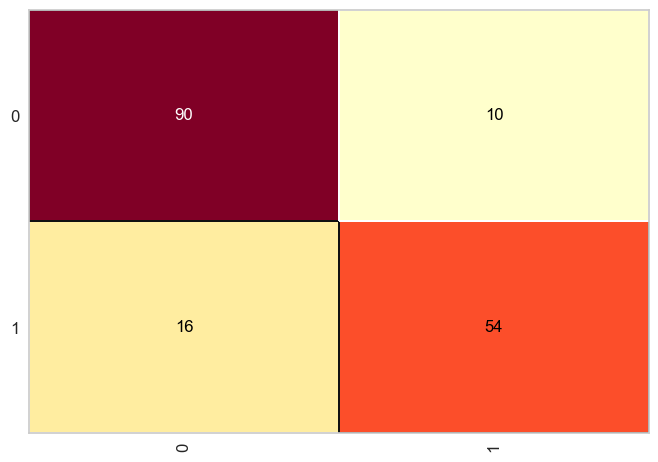

In [151]:
ensemble.fit(X_train, y_train)
cm = ConfusionMatrix(ensemble)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### Deep Learning

In [152]:
deep_learning_model.fit(X_train, y_train, epochs=200, batch_size=16, validation_split=0.2)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.8461 - loss: 0.4013 - val_binary_accuracy: 0.8456 - val_loss: 0.3769
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 806us/step - binary_accuracy: 0.8542 - loss: 0.3886 - val_binary_accuracy: 0.8382 - val_loss: 0.3860
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 857us/step - binary_accuracy: 0.8692 - loss: 0.3520 - val_binary_accuracy: 0.8382 - val_loss: 0.3796
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 786us/step - binary_accuracy: 0.8326 - loss: 0.4068 - val_binary_accuracy: 0.8382 - val_loss: 0.3899
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step - binary_accuracy: 0.8567 - loss: 0.3925 - val_binary_accuracy: 0.8309 - val_loss: 0.3864
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step - binary_accuracy: 0.8100 - loss: 0.4320 - val_binary_accuracy: 0.8235 - val_loss: 0.3908
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - binary_accuracy: 0.8228 - loss: 0.4178 - val_binary_accuracy: 0.8235 - val_loss: 0.3916
E

In [153]:
loss, accuracy = deep_learning_model.evaluate(X_test, y_test)
print(f"Acurácia no conjunto de teste: {accuracy:.2f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.8430 - loss: 0.4118  
Acurácia no conjunto de teste: 0.84


In [154]:
data_test.shape

(418, 8)

In [155]:
data_test.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,0.447368,0,0,0.013672,1,1,0
1,3,0.618421,1,0,0.013672,0,0,1
2,2,0.815789,0,0,0.017578,1,1,0
3,3,0.355263,0,0,0.015625,1,0,1
4,3,0.289474,1,1,0.023438,0,0,1


##### Oversampling - SMOTE

In [156]:
from imblearn.over_sampling import SMOTE

In [157]:
smote = SMOTE(sampling_strategy='minority')
X_over, y_over = smote.fit_resample(X, y) 

In [158]:
X_over.shape, y_over.shape

((1098, 8), (1098,))

In [159]:
X_over.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,0.2750,1,0,0.013672,1,0,1
1,1,0.4750,1,0,0.138672,0,0,0
2,3,0.3250,0,0,0.013672,0,0,1
3,1,0.4375,1,0,0.103516,0,0,1
4,3,0.4375,0,0,0.015625,1,0,1


In [160]:
# Split data from tomek
X_train, X_test, y_train, y_test = train_test_split(X_over, y_over, test_size=0.2, random_state=42)


#### Random forest

In [161]:
random_model.fit(X_train,y_train)


RandomForestClassifier(n_estimators=40)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.8363636363636363

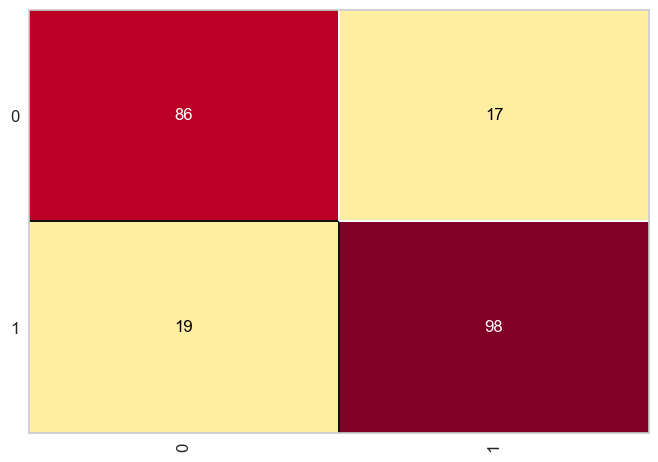

In [162]:
cm = ConfusionMatrix(random_model)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### KNN

In [163]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


0.8181818181818182

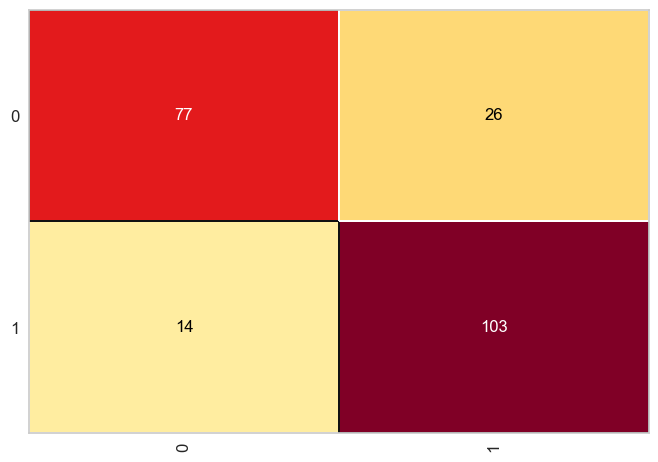

In [164]:
cm = ConfusionMatrix(knn)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### SVM

In [165]:
svm.fit(X_train, y_train)

SVC(kernel='sigmoid', probability=True)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


0.4318181818181818

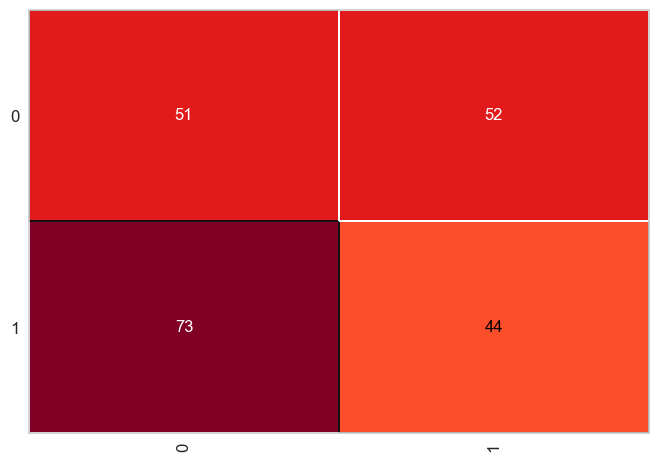

In [166]:
cm = ConfusionMatrix(svm)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### Logistic Regression

In [167]:
logistic_model.fit(X_train, y_train)

LogisticRegression()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


0.8227272727272728

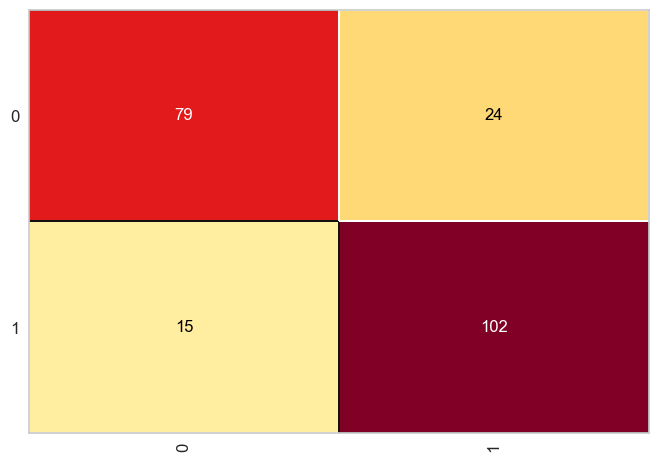

In [168]:
cm = ConfusionMatrix(logistic_model)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### Ensemble

In [169]:
ensemble.fit(X_train, y_train)


VotingClassifier(estimators=[('logistic', LogisticRegression()),
                             ('knn', KNeighborsClassifier()),
                             ('rf', RandomForestClassifier(n_estimators=40)),
                             ('xgboost',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metr...
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=None, ...))],
                 voting='soft', weights=[1, 1, 1, 2])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


0.8681818181818182

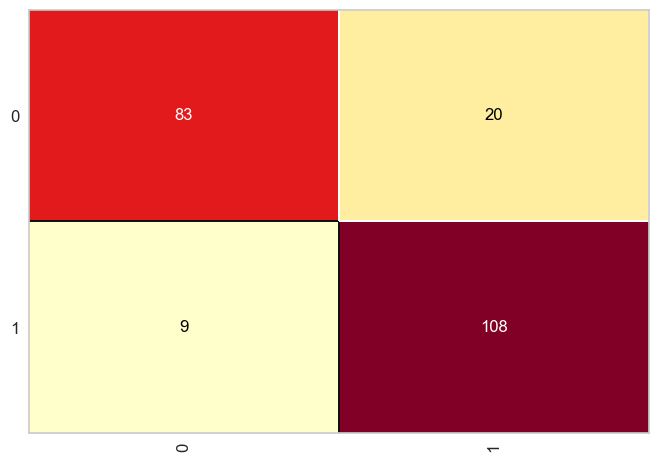

In [170]:
cm = ConfusionMatrix(ensemble)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### Deep learning

In [171]:
deep_learning_model.fit(X_train, y_train, epochs=200, batch_size=16, validation_split=0.2)

Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - binary_accuracy: 0.7993 - loss: 0.5177 - val_binary_accuracy: 0.8068 - val_loss: 0.4786
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - binary_accuracy: 0.8193 - loss: 0.4495 - val_binary_accuracy: 0.8068 - val_loss: 0.4699
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - binary_accuracy: 0.8165 - loss: 0.4470 - val_binary_accuracy: 0.8011 - val_loss: 0.4664
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 752us/step - binary_accuracy: 0.8102 - loss: 0.4261 - val_binary_accuracy: 0.7955 - val_loss: 0.4679
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step - binary_accuracy: 0.8428 - loss: 0.4004 - val_binary_accuracy: 0.7841 - val_loss: 0.4629
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - binary_accuracy: 0.8284 - loss: 0.4272 - val_binary_accuracy: 0.7841 - val_loss: 0.4626
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - binary_accuracy: 0.8150 - loss: 0.4388 - val_binary_accuracy: 0.7955 - val_loss: 0.4627
E

In [172]:
loss, accuracy = deep_learning_model.evaluate(X_test, y_test)
print(f"Accuracy on the test set: {accuracy:.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - binary_accuracy: 0.8601 - loss: 0.3736
Acurácia no conjunto de teste: 0.86


#### XGBBoost

In [173]:
from xgboost import XGBClassifier


In [174]:
xgboost.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

0.8818181818181818

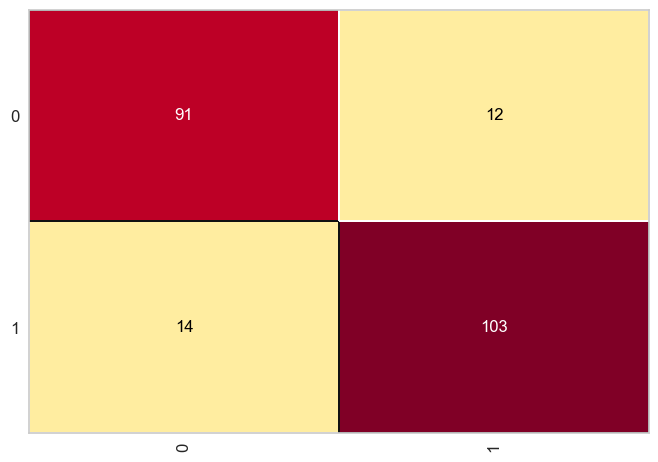

In [175]:
cm = ConfusionMatrix(xgboost)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

In [221]:

# Load test.csv
test_df = pd.read_csv('test.csv')

# Save PassengerId
passenger_ids = test_df['PassengerId']
predictions = xgboost.predict(data_test)
predictions

# Create DataFrame 
result_df = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': predictions
})

# Save CSV to submission
result_df.to_csv('predicoes_titanic_xgboost_reduzindo_amostras.csv', index=False)

#### We can conclude, based on the techniques applied and the accuracies obtained, that the XGBoost model using undersampling achieved the best results in the Kaggle submission. Interestingly, it was also the best-performing algorithm in our oversampling tests, reaching 88% accuracy, although it performed worse on Kaggle with only 76% accuracy. The deep learning model came in second, achieving 85% accuracy in the notebook and 77.5% on Kaggle. Our goal was to achieve over 80% accuracy in the notebook and at least 75% on Kaggle, and with these results, we can consider that we are on the right track.